In [1]:
from gaussian_mixture_score_creation import *

/home/vguarin/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = load_config(config_path='/fast/AG_Kainmueller/vguarin/aggrigator_experiments/spatial/spatial_configs/arctique.toml')
# config = load_config(config_path='/fast/AG_Kainmueller/vguarin/aggrigator_experiments/spatial/spatial_configs/lidc.toml')
# config = load_config(config_path='/fast/AG_Kainmueller/vguarin/aggrigator_experiments/spatial/spatial_configs/gta.toml')
dataset_name = config['dataset']['dataset_name']

print(f"Loaded configuration for dataset: '{dataset_name}'")

paths = {
    'id_spatial': config['paths'].get('id_csv_path_spatial'),
    'ood_spatial': config['paths'].get('ood_csv_path_spatial'),
    'id_magnitude': config['paths'].get('id_csv_path_magnitude'),
    'ood_magnitude': config['paths'].get('ood_csv_path_magnitude')
}

base_filename = config['paths'].get('base_filename', 'fingerprints')

Loaded configuration for dataset: 'arctique'


In [3]:
id_spatial = load_spatial_fingerprints(paths['id_spatial'], base_filename)
ood_spatial = load_spatial_fingerprints(paths['ood_spatial'], base_filename)
id_magnitude = load_magnitude_fingerprints(paths['id_magnitude'], base_filename)
ood_magnitude = load_magnitude_fingerprints(paths['ood_magnitude'], base_filename)

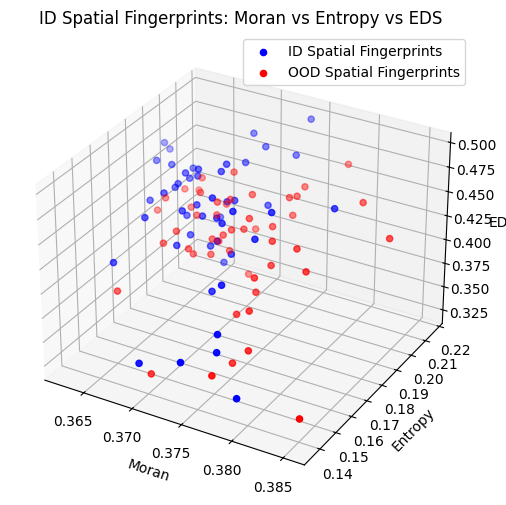

In [4]:
import matplotlib.pyplot as plt

# plot spatial fingerprints
plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.scatter(id_spatial['moran'], id_spatial['entropy'], id_spatial['eds'], label='ID Spatial Fingerprints', color='blue')
ax.scatter(ood_spatial['moran'], ood_spatial['entropy'], ood_spatial['eds'], label='OOD Spatial Fingerprints', color='red')
ax.set_xlabel('Moran')
ax.set_ylabel('Entropy')
ax.set_zlabel('EDS')
ax.legend()
ax.set_title('ID Spatial Fingerprints: Moran vs Entropy vs EDS')
plt.show()

In [5]:
# add id_spatial index name uq_map_name
id_spatial.index.name = 'uq_map_name'
id_magnitude.index = id_magnitude.index.astype('str')
id_spatial.index = id_spatial.index.astype('str')

# give a different name to ood spatial and ood magnitude
ood_spatial.index.name = 'uq_map_name'
ood_magnitude.index = ood_magnitude.index.astype('str')
ood_spatial.index = ood_spatial.index.astype('str')

ood_spatial.index = [f"ood_{idx}" for idx in ood_spatial.index]
ood_magnitude.index = [f"ood_{idx}" for idx in ood_magnitude.index]

In [6]:
id_magnitude
# remove 0s before index
id_magnitude.index = id_magnitude.index.str.lstrip('0')

In [7]:
# join id_spatial and id_magnitude via the index uq_map_name
# id_magnitudex.set_index('uq_map_name', inplace=True)
id_fingerprints = id_spatial.join(id_magnitude)
ood_fingerprints = ood_spatial.join(ood_magnitude)
all_fingerprints = pd.concat([id_fingerprints, ood_fingerprints], axis=0)
all_fingerprints

,moran,entropy,eds,mean,above_threshold_mean_0.3,above_threshold_mean_0.5,above_threshold_mean_0.7,above_threshold_mean_0.9,above_threshold_mean_0.95,above_quantile_mean_0.3,...,above_quantile_mean_0.7,above_quantile_mean_0.9,above_quantile_mean_fg_ratio,patch_aggregation_10,patch_aggregation_20,patch_aggregation_40,patch_aggregation_80,patch_aggregation_100,"class_mean_w_equal_weights_configurable_{'include_background': False, 'ignore_index': 0}","class_mean_weighted_by_occurrence_configurable_{'include_background': False, 'ignore_index': 0}"
308,0.363930,0.176630,0.439386,0.288251,0.499296,0.648563,0.818038,1.044250,1.079078,0.388677,...,0.565306,0.721477,0.611979,1.175020,0.780291,0.570919,0.456345,0.426039,0.577365,0.467220
235,0.366302,0.186865,0.454760,0.351740,0.507385,0.659098,0.817319,1.021858,1.056876,0.454701,...,0.622304,0.770466,0.642266,1.088037,0.900872,0.733460,0.552249,0.525914,0.616081,0.516214
309,0.363537,0.156957,0.401535,0.471907,0.544371,0.646305,0.793841,0.997042,1.041929,0.573776,...,0.701299,0.804215,0.668740,1.094160,0.812311,0.762020,0.706070,0.681711,0.662697,0.551175
254,0.368258,0.175747,0.417140,0.350821,0.510813,0.670314,0.838122,1.031571,1.068266,0.462123,...,0.634433,0.796059,0.666789,1.205630,0.895693,0.600251,0.513285,0.512103,0.709272,0.561466
312,0.378015,0.145362,0.322954,0.500962,0.543860,0.632081,0.845951,1.039513,1.074904,0.587315,...,0.700377,0.835560,0.710283,1.204541,0.871445,0.677592,0.590700,0.588267,0.691827,0.562485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ood_252,0.366909,0.188904,0.441427,0.370708,0.502272,0.667559,0.840963,1.034652,1.070532,0.464354,...,0.629294,0.788922,0.659497,1.063027,0.814750,0.624589,0.539696,0.510280,0.691631,0.523099
ood_212,0.376955,0.172777,0.415183,0.351931,0.526663,0.657460,0.843317,1.042405,1.077281,0.478067,...,0.650359,0.790387,0.671178,1.270317,0.927054,0.713302,0.558464,0.544319,0.694104,0.532604
ood_204,0.376804,0.138027,0.354770,0.527252,0.575783,0.664432,0.832025,1.030572,1.068548,0.626475,...,0.760865,0.906373,0.755325,1.192139,0.872455,0.741150,0.664585,0.644009,0.747732,0.645435
ood_232,0.376479,0.176399,0.433294,0.322022,0.508973,0.664276,0.839826,1.037390,1.069356,0.435854,...,0.614125,0.769646,0.638342,1.141250,0.891330,0.603305,0.528160,0.507572,0.695224,0.508675


# Build adata object

In [11]:
import anndata

# put all id_fingerprints in anndata object
adata = anndata.AnnData(all_fingerprints_transformed)

# add info of ood sample and iid sample
adata.obs['sample_type'] = ['ood' if idx.startswith('ood_') else 'id' for idx in adata.obs_names]

In [14]:
# cluster the fingerprints with scanpy using leiden clustering, umap 
import scanpy as sc

# do PCA
sc.pp.pca(adata, n_comps=3, svd_solver='arpack')
print("PCA computed.")
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X')#_pca')
print("Neighbors computed.")
sc.tl.leiden(adata, resolution=1.0)
print("Leiden clustering done.")
sc.tl.umap(adata)
print("UMAP computed.")

PCA computed.
Neighbors computed.
Leiden clustering done.


/tmp/ipykernel_2479111/2570671273.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0)


UMAP computed.


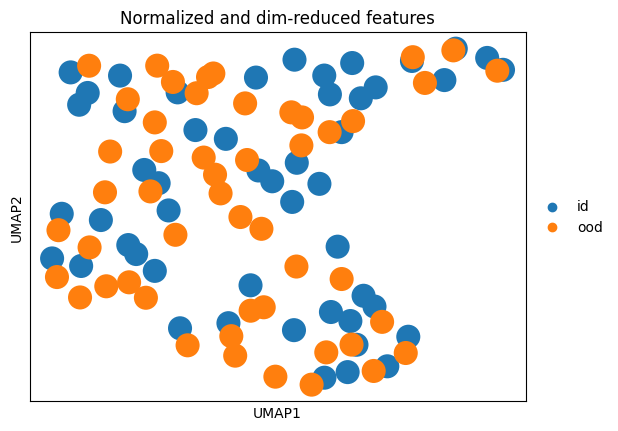

In [15]:
# plot umap

sc.pl.umap(adata, color=['sample_type'], title='Normalized and dim-reduced features', save=f'_{dataset_name}_spatial_fingerprints_umap.png')

# Data distribution

Text(0.5, 1.0, 'Transformed Data Distribution')

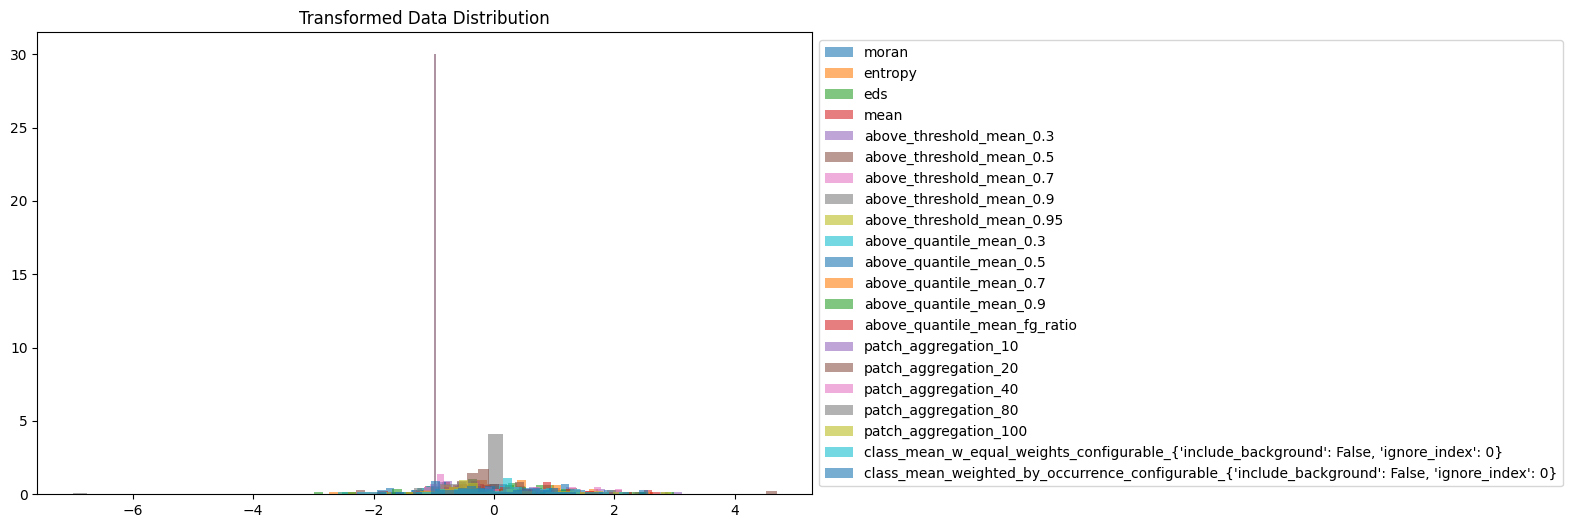

In [8]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))

id_fingerprints_transformed = id_fingerprints.copy()
trasnformation = {}

for sel_metric in id_fingerprints:
    data = id_fingerprints[sel_metric].values.flatten()
    
    # add small offset to avoid log(0)
    data = np.clip(data, a_min=1e-10, a_max=1-1e-10)
    data = norm.ppf(data)

    # norm with mean and std
    mean = data.mean()
    std = data.std()
    data = (data - mean) / std

    # store transformed data
    id_fingerprints[sel_metric] = data
    trasnformation[sel_metric] = (mean, std)
    plt.hist(data, bins=30, density=True, alpha=0.6, label=sel_metric)

# add legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Transformed Data Distribution')

Text(0.5, 1.0, 'Transformed Data Distribution')

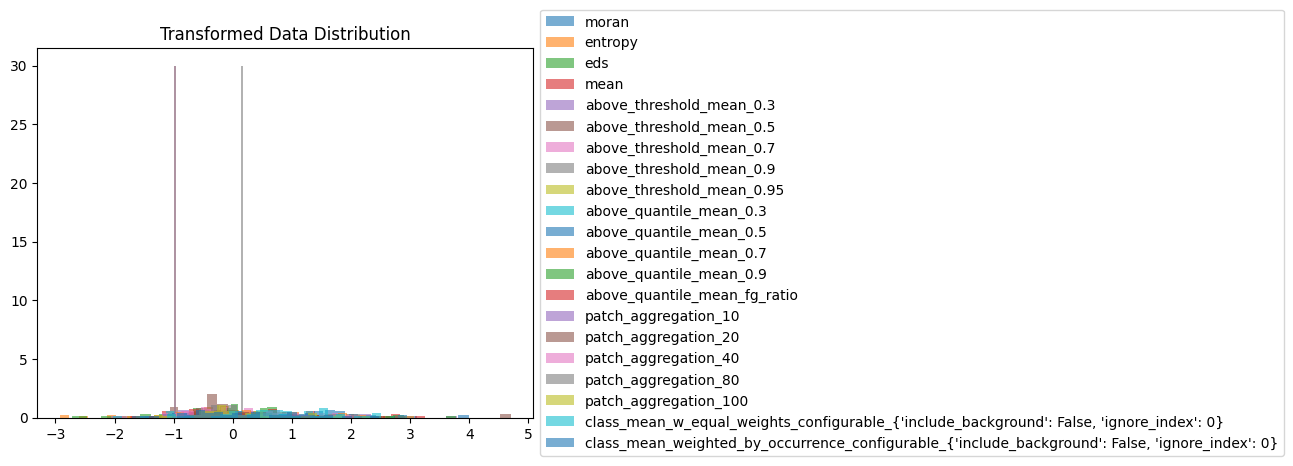

In [9]:
# transform ood_fingerprints using the same mean and std
ood_fingerprints_transformed = ood_fingerprints.copy()

for sel_metric in ood_fingerprints_transformed:
    mean, std = trasnformation[sel_metric]
    data = ood_fingerprints_transformed[sel_metric].values.flatten()
    data = np.clip(data, a_min=1e-10, a_max=1-1e-10)
    data = norm.ppf(data)
    data = (data - mean) / std
    ood_fingerprints_transformed[sel_metric] = data
    plt.hist(data, bins=30, density=True, alpha=0.6, label=sel_metric)

# add legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Transformed Data Distribution')

In [10]:
all_fingerprints_transformed = pd.concat([id_fingerprints, ood_fingerprints_transformed], axis=0)